# Objective 1 : Profile & explore the data
## Objective here is to import the data and explore relationships between the features and target variable.

### Task : Build a classification model that identifies the customer with highest risk of churn 

### Import the “Bank_Churn.csv” file and set an appropriate data type for each column


In [1]:
import pandas as pd
cust_df = pd.read_csv('Bank_Churn.csv')

cust_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
cust_df.dtypes

CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

### Check for missing values and calculate the min, max, and mean for numeric columns

In [3]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [4]:
cust_df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Build a scatterplot matrix to find relationships between all pairs of numeric columns

In [5]:
import seaborn as sns

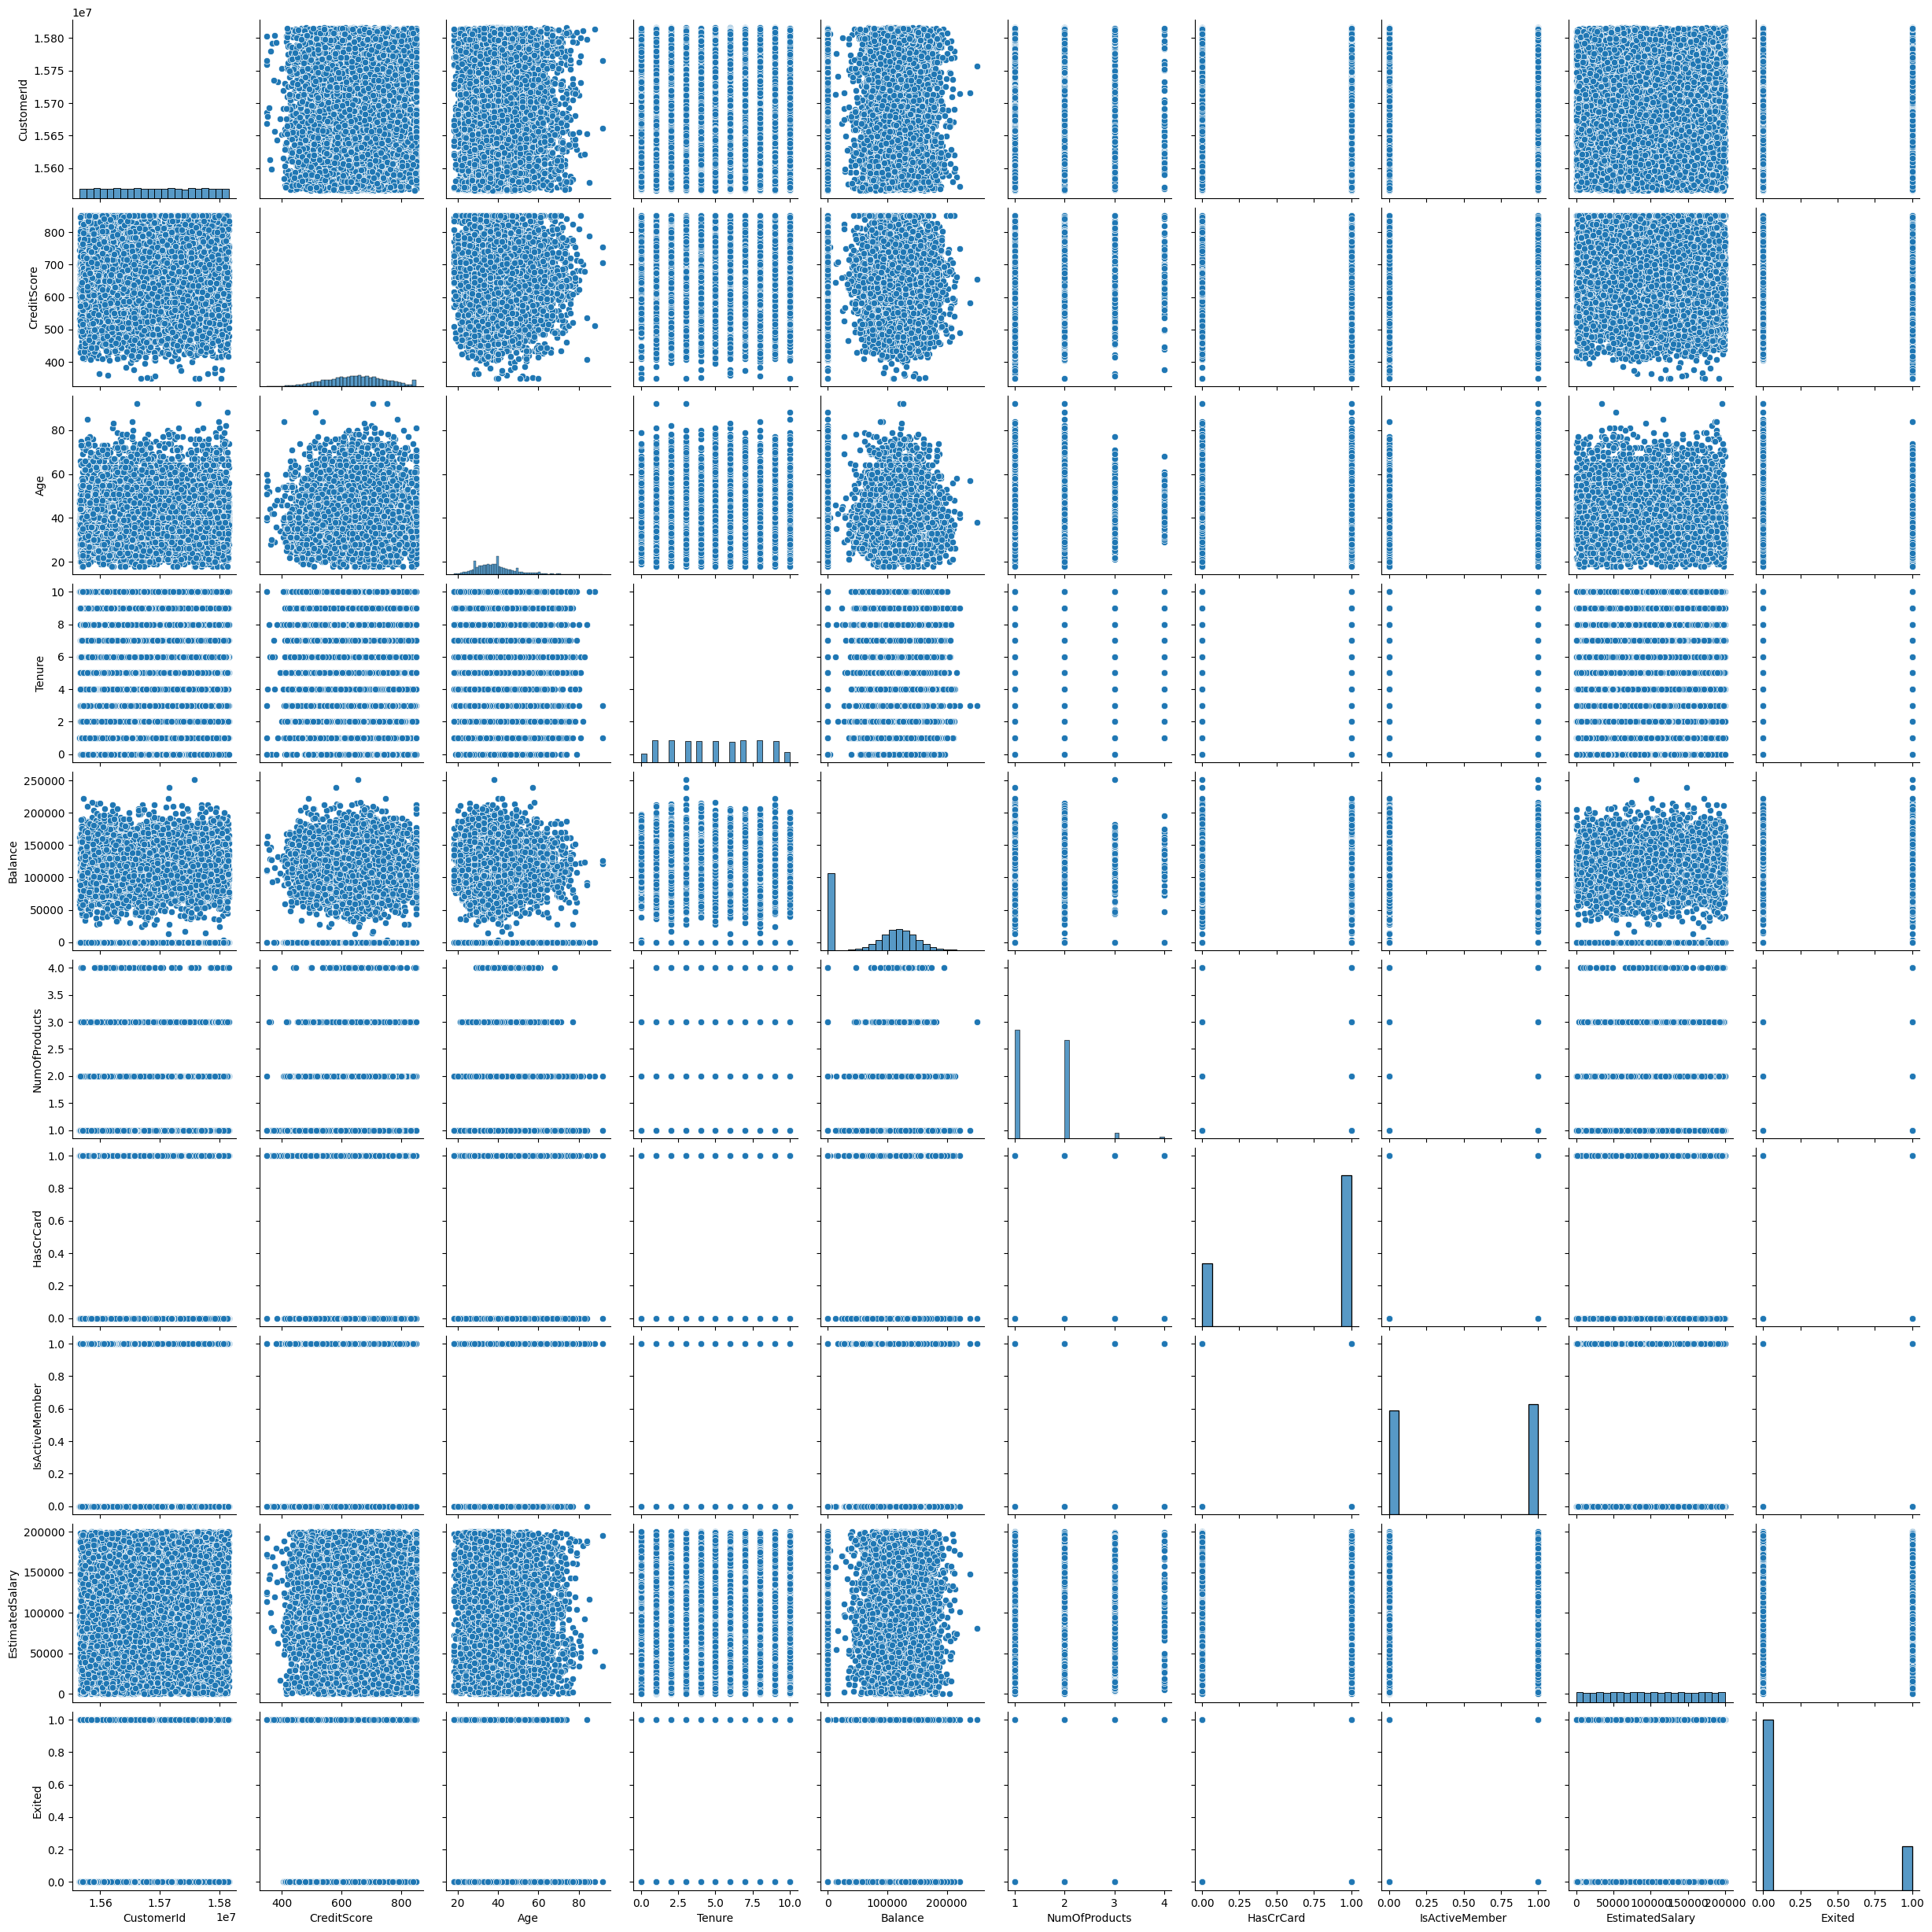

In [6]:
sns.pairplot(cust_df)

<Axes: >

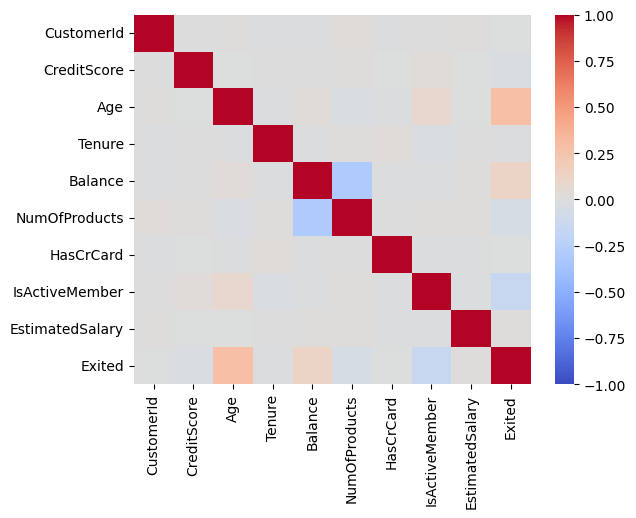

In [7]:
sns.heatmap(cust_df.corr(numeric_only=True),vmin=-1, vmax=1,cmap="coolwarm")

### Build box plots for each numeric column broken out by the target variable, “Exited”

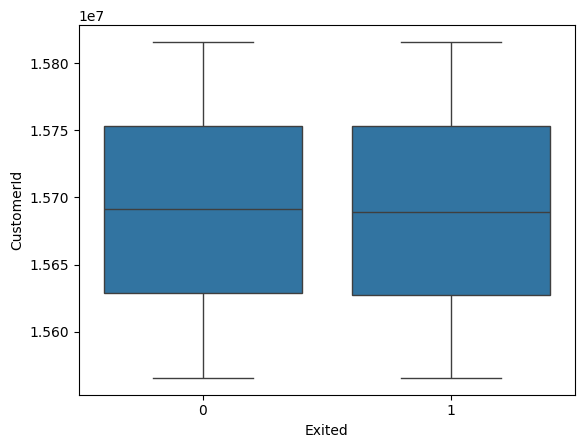

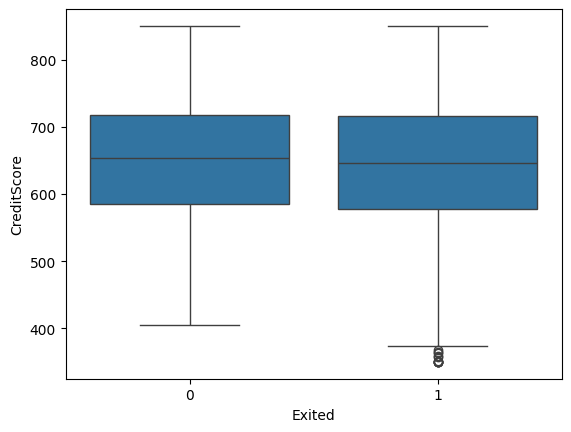

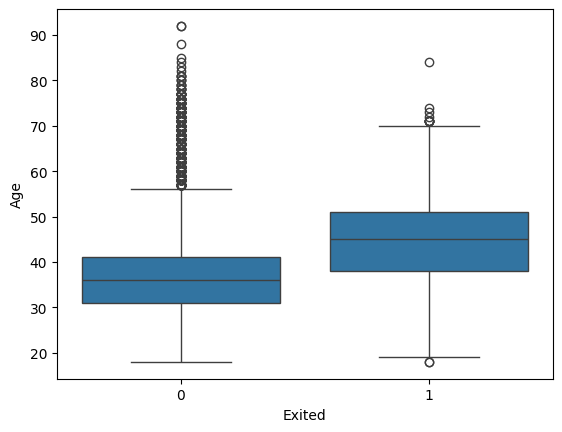

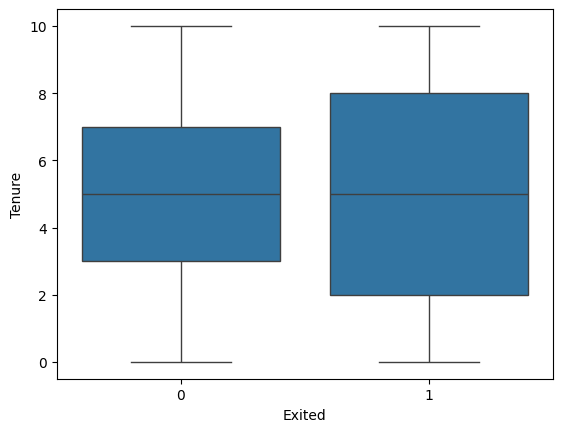

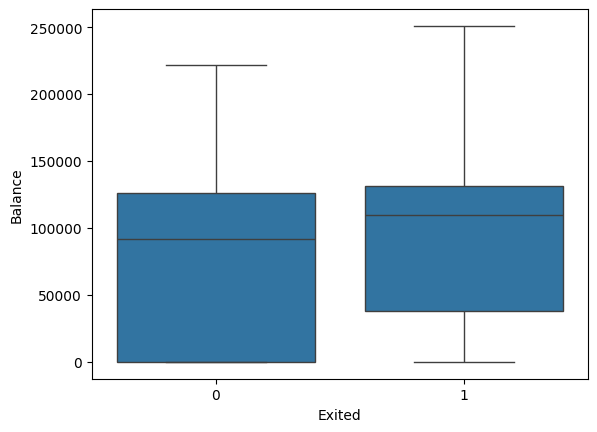

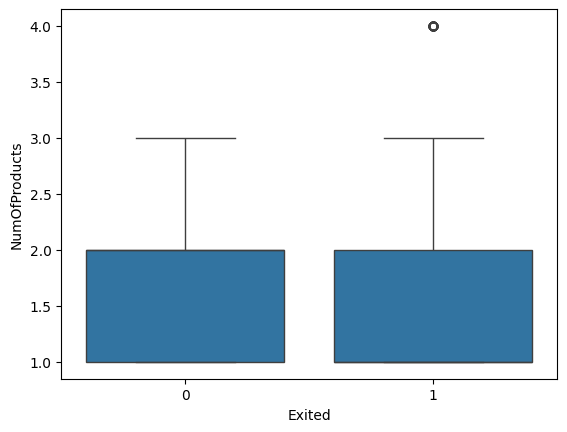

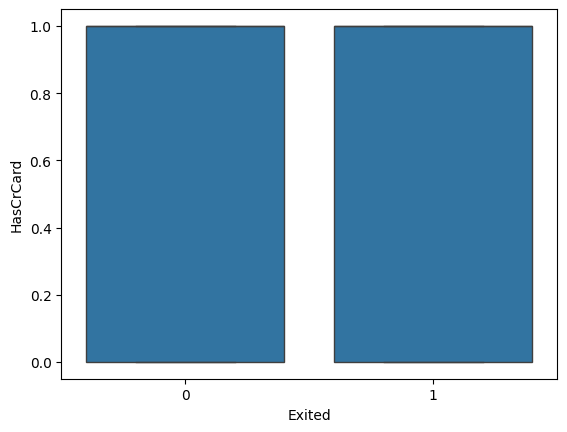

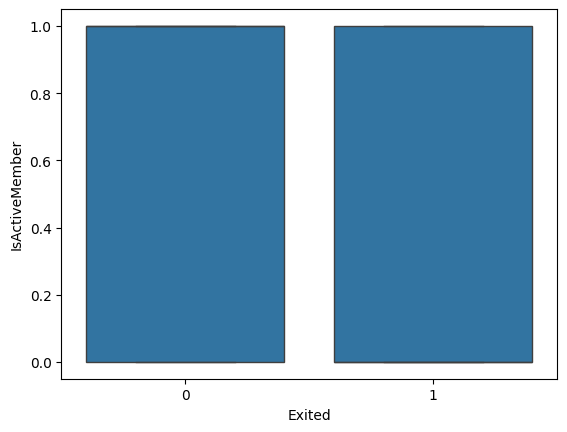

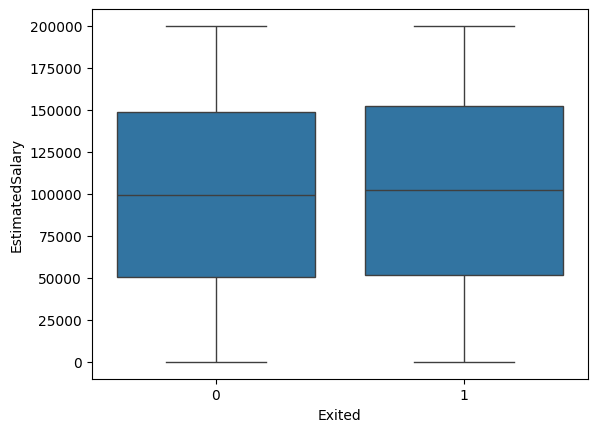

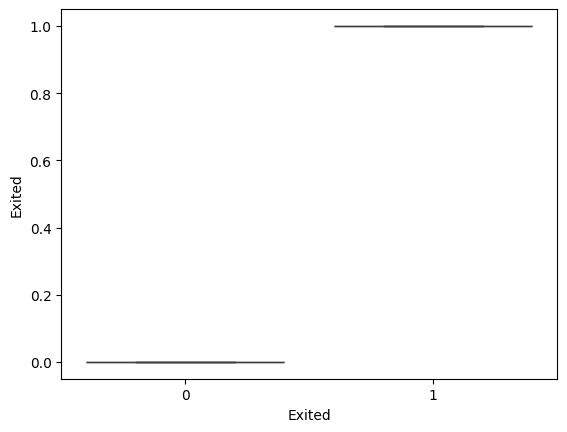

In [8]:
import matplotlib.pyplot as plt

for col in cust_df.select_dtypes("number"):
    sns.boxplot(data=cust_df,y=col,x="Exited")
    plt.show()

### Build bar charts that show the percentage of “Exited” by category for each categorical column

In [9]:
cust_df.select_dtypes("object").columns[1:]

Index(['Geography', 'Gender'], dtype='object')

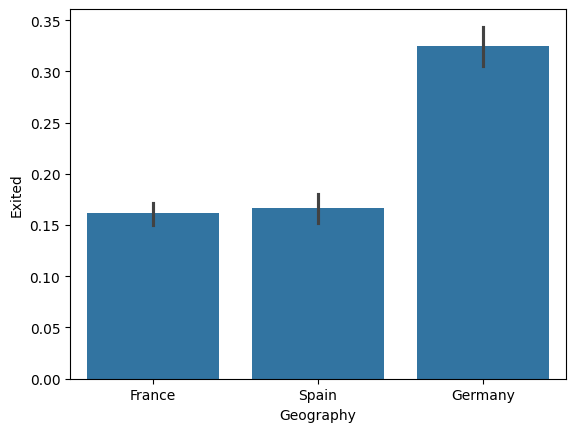

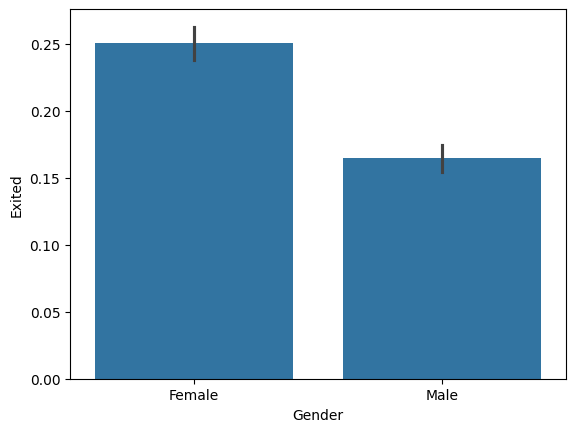

In [10]:
for col in cust_df.select_dtypes("object").columns[1:]:
    sns.barplot(data =cust_df, x=col,y="Exited")
    plt.show()

# Objective 2 : Prepare the data for modeling
## Second objective is to prepare the data for modeling through feature selection, feature engineering, and data splitting.

### Drop columns that aren’t suitable for modeling from the dataset

In [11]:
cust_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
cust_modelling_df = cust_df.drop(["CustomerId", "Surname"],axis=1)


### Create a new column, “balance_to_income”, by dividing “Balance” by “EstimatedSalary”
### Create a new column, “income_v_products”, by dividing “EstimatedSalary” by “NumOfProducts”

In [13]:
cust_modelling_df = cust_modelling_df.assign(
    balance_to_income = cust_modelling_df['Balance']/cust_modelling_df['EstimatedSalary'],
    income_v_products = cust_modelling_df['EstimatedSalary']/cust_modelling_df['NumOfProducts']
)

cust_modelling_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_income,income_v_products
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,101348.880
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677,112542.580
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375,37977.190
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,46913.315
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055,79084.100


In [14]:
cust_modelling_df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_income,income_v_products
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,3.878703,74715.158001
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,108.337260,52058.899406
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,32589.780000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.747002,65908.002500
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.514022,100943.797500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,10614.655440,199970.740000


<Axes: xlabel='Exited', ylabel='balance_to_income'>

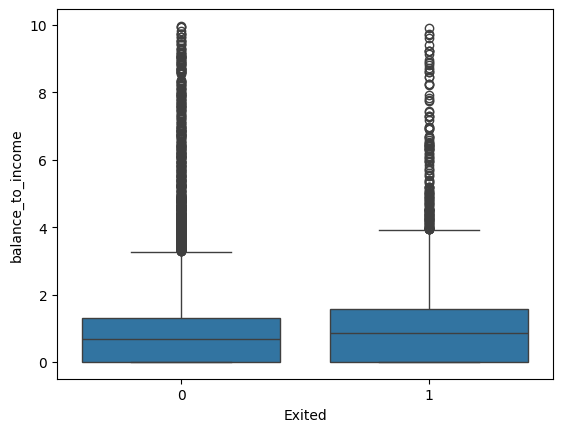

In [15]:
sns.boxplot(data=cust_modelling_df.query("balance_to_income < 10"), x ="Exited", y="balance_to_income")

<Axes: xlabel='Exited', ylabel='income_v_products'>

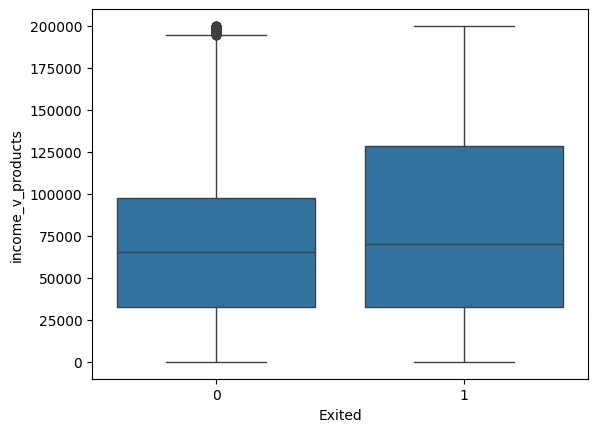

In [16]:
sns.boxplot(data=cust_modelling_df, x ="Exited", y="income_v_products")

### Create dummy variables for categorical columns

In [17]:
cust_modelling_df = pd.get_dummies(cust_modelling_df, drop_first = True , dtype=int)
cust_modelling_df 

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_income,income_v_products,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,101348.880,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744677,112542.580,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401375,37977.190,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,46913.315,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587055,79084.100,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0.000000,48135.320,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0.564108,101699.770,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0.000000,42085.580,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0.808230,46444.260,1,0,1


### Split the data into train and test sets, with 20% of the rows in the test set

In [18]:
pip install scikit-learn


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
from sklearn.model_selection import train_test_split

x = cust_modelling_df.drop("Exited",axis=1)
y = cust_modelling_df["Exited"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state=2026)

x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 4098 to 1754
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        2000 non-null   int64  
 1   Age                2000 non-null   int64  
 2   Tenure             2000 non-null   int64  
 3   Balance            2000 non-null   float64
 4   NumOfProducts      2000 non-null   int64  
 5   HasCrCard          2000 non-null   int64  
 6   IsActiveMember     2000 non-null   int64  
 7   EstimatedSalary    2000 non-null   float64
 8   balance_to_income  2000 non-null   float64
 9   income_v_products  2000 non-null   float64
 10  Geography_Germany  2000 non-null   int64  
 11  Geography_Spain    2000 non-null   int64  
 12  Gender_Male        2000 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 218.8 KB


# Objective 3 : Build & evaluate a logistic regression modelBuild & evaluate a logistic regression model
## Here objective is to fit a logistic regression model and evaluate it by using a confusion matrix, ROC curve, and precision & recall.

### Fit a logistic regression model on your training data

In [20]:
x_train2 = x_train.drop(['Balance','EstimatedSalary','income_v_products'],axis=1)

In [21]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(solver="newton-cholesky")

lr = logreg.fit(x_train,y_train)

print(f"Training_Score: {lr.score(x_train,y_train)}")

Training_Score: 0.81225


### Build a confusion matrix to evaluate your model

In [22]:
from sklearn.metrics import confusion_matrix , precision_score, recall_score, f1_score

confusion_matrix(y_train,lr.predict(x_train))

array([[6081,  267],
       [1235,  417]])

### Calculate accuracy, precision, recall, and F1 for your test data

In [23]:

precision_score(y_train,lr.predict(x_train))

0.6096491228070176

In [24]:
recall_score(y_train,lr.predict(x_train))

0.2524213075060533

In [25]:
f1_score(y_train,lr.predict(x_train))

0.3570205479452055

In [26]:
list(zip(x_train,lr.coef_[0]))

[('CreditScore', np.float64(-0.000864107629738628)),
 ('Age', np.float64(0.07341204088228095)),
 ('Tenure', np.float64(-0.00966162229001328)),
 ('Balance', np.float64(2.004207081968069e-06)),
 ('NumOfProducts', np.float64(0.8145922208705502)),
 ('HasCrCard', np.float64(-0.08309635655388936)),
 ('IsActiveMember', np.float64(-1.0943952353344122)),
 ('EstimatedSalary', np.float64(-1.6158243932294936e-05)),
 ('balance_to_income', np.float64(0.002706575842509971)),
 ('income_v_products', np.float64(2.2139378733413977e-05)),
 ('Geography_Germany', np.float64(0.7635568028921187)),
 ('Geography_Spain', np.float64(0.015068082940862176)),
 ('Gender_Male', np.float64(-0.5302035011856852))]

In [27]:
confusion_matrix(y_test,lr.predict(x_test))

array([[1565,   50],
       [ 285,  100]])

In [28]:

print(f"Test_Accuracy: {lr.score(x_test,y_test)}")

Test_Accuracy: 0.8325


In [29]:
precision_score(y_test,lr.predict(x_test))

0.6666666666666666

In [30]:
recall_score(y_test,lr.predict(x_test))

0.2597402597402597

In [31]:
f1_score(y_test,lr.predict(x_test))

0.37383177570093457

### Plot an ROC curve and calculate the AUC statistic

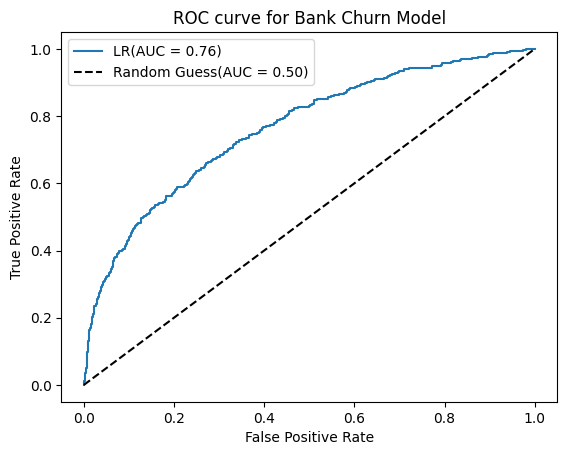

In [32]:
from sklearn.metrics import roc_curve, auc

y_probs = lr.predict_proba(x_test)[:, 1]
fpr1,tpr1,thresholds = roc_curve(y_test,y_probs)
auc_score = auc(fpr1,tpr1)

# plot the ROC curve
plt.plot(fpr1,tpr1,label = f'LR(AUC = {auc_score:.2f})')

# Draw random guess
plt.plot([0,1],[0,1],'k--',label='Random Guess(AUC = 0.50)')

# Modify Formatting

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for Bank Churn Model')
plt.legend()
plt.show()

### Plot precision and recall against the model threshold (set the threshold to the value where recall is the highest, but precision is still above 50%)

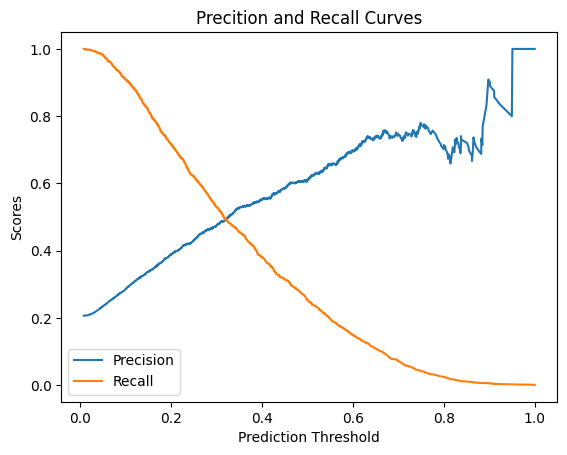

In [33]:
from sklearn.metrics import precision_recall_curve

p_curve,r_curve,t_curve = precision_recall_curve(y_train,lr.predict_proba(x_train)[:, 1])

# plot 
plt.plot(t_curve,p_curve[:-1],label='Precision')
plt.plot(t_curve,r_curve[:-1],label='Recall')

plt.xlabel('Prediction Threshold')
plt.ylabel('Scores')
plt.title('Precition and Recall Curves')
plt.legend()
plt.show()

In [34]:
pip install numpy


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [35]:
import numpy as np

np.where(p_curve>0.5)

(array([6401, 6402, 6403, ..., 7998, 7999, 8000]),)

In [36]:
t_curve[6401]

np.float64(0.3263043446484404)

In [37]:
confusion_matrix(y_test,lr.predict_proba(x_test)[:, 1] > 0.32)

array([[1441,  174],
       [ 209,  176]])

In [38]:
precision_score(y_test,lr.predict_proba(x_test)[:, 1] > 0.32)

0.5028571428571429

In [39]:
recall_score(y_test,lr.predict_proba(x_test)[:, 1] > 0.32)

0.45714285714285713

# Objective 4 : Fit & tune a random forest model

## Final objective is to fit a random forest model, tune it using cross validation, and evaluate test accuracy, AUC score, and feature importance.

### Fit a random forest model with default hyperparameters

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf = rf.fit(x_train,y_train)

print(f"Training Accuracy: {rf.score(x_train,y_train)}")
print(f"Test Accuracy: {rf.score(x_test,y_test)}")

Training Accuracy: 1.0
Test Accuracy: 0.8655


### Use cross validation to tune your model's hyperparameters

In [41]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

rf = RandomForestClassifier(random_state=2026, n_jobs=-1)

params = { 
    'n_estimators': np.arange(start=100, stop=1100, step=100),
    'max_depth': np.arange(start=1, stop=11, step=1),
    'min_samples_leaf': [2, 5, 10, 20, 100],
    'max_features': [None, "sqrt"],
    'bootstrap': [True],
    'max_samples': [None, 0.3, 0.5, 0.9] 
}

grid = RandomizedSearchCV(
    rf,
    params,
    n_iter=100,
    scoring="accuracy" 
)

grid.fit(x_train, y_train)
grid.best_params_

{'n_estimators': np.int64(900),
 'min_samples_leaf': 5,
 'max_samples': 0.5,
 'max_features': None,
 'max_depth': np.int64(9),
 'bootstrap': True}

In [ ]:
from sklearn.model_selection import GridSearchCV

params = { 
    'n_estimators': np.arange(start=850, stop=951, step=10),
    'max_depth': [8,10,12] ,
    'min_samples_leaf': [5,10,15],
    'max_samples': [0.4, 0.5, 0.6]
}

grid = GridSearchCV(
    rf,
    params,
    scoring="accuracy"
)

grid.fit(x_train,y_train)
grid.best_params_

### Report the final test accuracy and AUC score

In [ ]:
rf = RandomForestClassifier(**{
    'n_estimators': 890,
    'max_depth': 12,
    'min_samples_leaf': 5,
    'bootstrap': True,
    'max_samples': 0.5 
}

rf.fit(x_train, y_train)
                            
print(f"Training Accuracy: {rf.score(x_train,y_train)}")
print(f"Test Accuracy: {rf.score(x_test,y_test)}")

In [ ]:
from sklearn.metrics import roc_curve, auc

y_probs = lr.predict_proba(x_test)[:, 1]
fpr1,tpr1,thresholds = roc_curve(y_test,y_probs)
auc_score = auc(fpr1,tpr1)

auc_score

### Build a bar chart that shows feature importance

In [ ]:
importance = pd.DataFrame(
{ "feature": x_train.columns,
  "importance":rf.feature_importances_}.sort_values("importance",ascending=False).iloc[:20])

sns.barplot(importance,x="importance",y="feature")